# Vector ADD

在本教程中，将使用 Triton 编写一个简单的向量相加 (vector addition) 程序。

同时还将了解：

1. Triton 的基本编程模型
2. 用于定义 Triton 内核的 triton.jit 装饰器 (decorator)
3. 验证和基准测试自定义算子与原生参考实现的最佳实践

In [1]:
import triton
import triton.language as tl
import torch

DEVICE = triton.runtime.driver.active.get_active_torch_device()

## Compute kernel

In [2]:
# 向量加的计算核心实现
@triton.jit
def add_kernel(
    x_ptr, # pointer of the input vector x 
    y_ptr, # pointer of the input vector y
    o_ptr, # pointer of the output vector o 
    n_elements, # Size of the vector.
    BLOCK_SIZE: tl.constexpr # Number of elements each program should process.
                             # NOTE: `constexpr` so it can be used as a shape value.
):
    '''
    Compute element-wise addition: o = x + y.
    '''
    # ID of the current Triton program instance
    pid = tl.program_id(0)

    # Integer offsets processed by this program
    offs = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)

    # Prevent out-of-bounds memory access
    mask = offs < n_elements

    # Load data from global memory
    x = tl.load(x_ptr + offs, mask=mask, other=0.0)
    y = tl.load(y_ptr + offs, mask=mask, other=0.0)

    # Element-wise addition
    # o = x + y 也可以
    o = tl.add(x, y)

    # Store valid results back to global memory
    tl.store(o_ptr+offs, o, mask=offs<n_elements)

In [3]:
# 如果想要使用我们用triton写的向量加核心，需要另外定义函数去调用上述核心
def add(x: torch.Tensor, y: torch.Tensor):
    # We need to preallocate the output.
    output = torch.empty_like(x)
    assert x.device == DEVICE and y.device == DEVICE and output.device == DEVICE
    n_elements = output.numel()
    # The SPMD launch grid denotes the number of kernel instances that run in parallel.
    # It is analogous to CUDA launch grids. It can be either Tuple[int], or Callable(metaparameters) -> Tuple[int].
    # In this case, we use a 1D grid where the size is the number of blocks:
    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']), )
    # NOTE:
    #  - Each torch.tensor object is implicitly converted into a pointer to its first element.
    #  - `triton.jit`'ed functions can be indexed with a launch grid to obtain a callable GPU kernel.
    #  - Don't forget to pass meta-parameters as keywords arguments.
    add_kernel[grid](x, y, output, n_elements, BLOCK_SIZE=256)
    # We return a handle to z but, since `torch.cuda.synchronize()` hasn't been called, the kernel is still
    # running asynchronously at this point.
    return output

In [4]:
# 这样就把计算的核心更换成了我们手写的向量加法核心
# 接下来我们可以与torch的运算结果对比，去验证这个核心的正确性
torch.manual_seed(0)
size = 98432
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([1.3713, 1.3076, 0.4940,  ..., 0.9592, 0.3409, 1.2567], device='cuda:0')
tensor([1.3713, 1.3076, 0.4940,  ..., 0.9592, 0.3409, 1.2567], device='cuda:0')
The maximum difference between torch and triton is 0.0


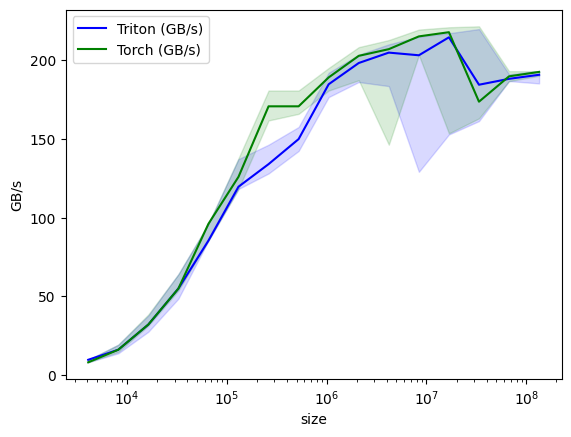

vector-add-performance:
           size  Triton (GB/s)  Torch (GB/s)
0        4096.0       9.600000      8.000000
1        8192.0      15.999999     15.999999
2       16384.0      31.999999     31.999999
3       32768.0      54.857142     54.857142
4       65536.0      85.333330     96.000000
5      131072.0     119.591245    125.869397
6      262144.0     133.929155    170.666661
7      524288.0     149.853661    170.666661
8     1048576.0     184.695159    189.046153
9     2097152.0     198.193551    202.740914
10    4194304.0     204.800005    206.996644
11    8388608.0     203.107443    215.107227
12   16777216.0     214.520460    217.765249
13   33554432.0     184.392023    173.605306
14   67108864.0     188.141619    189.730282
15  134217728.0     190.707976    192.540579


In [5]:
#更进一步的，我们可以对比torch默认实现和我们用triton实现的运算效率/速度
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],  # Argument names to use as an x-axis for the plot.
        x_vals=[2**i for i in range(12, 28, 1)],  # Different possible values for `x_name`.
        x_log=True,  # x axis is logarithmic.
        line_arg='provider',  # Argument name whose value corresponds to a different line in the plot.
        line_vals=['triton', 'torch'],  # Possible values for `line_arg`.
        line_names=['Triton', 'Torch'],  # Label name for the lines.
        styles=[('blue', '-'), ('green', '-')],  # Line styles.
        ylabel='GB/s',  # Label name for the y-axis.
        plot_name='vector-add-performance',  # Name for the plot. Used also as a file name for saving the plot.
        args={},  # Values for function arguments not in `x_names` and `y_name`.
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)
    quantiles = [0.5, 0.2, 0.8]
    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x, y), quantiles=quantiles)
    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(print_data=True, show_plots=True)

## Matrix ADD

1D向量相加总是最简单的，现在我们把目标拓展至二维乃至更高维的向量，可以看到我们之前的代码依然可以正确运行。

In [6]:
torch.manual_seed(0)
size = (1024, 1024)
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')


torch.manual_seed(0)
size = (128, 128, 128)
x = torch.rand(size, device=DEVICE)
y = torch.rand(size, device=DEVICE)
output_torch = x + y
output_triton = add(x, y)
print(output_torch)
print(output_triton)
print(f'The maximum difference between torch and triton is '
      f'{torch.max(torch.abs(output_torch - output_triton))}')

tensor([[0.6482, 1.2587, 0.8114,  ..., 0.8644, 0.6629, 1.5074],
        [0.6774, 1.5012, 0.4630,  ..., 0.6897, 1.1711, 0.4050],
        [0.8619, 1.0026, 1.6219,  ..., 0.8484, 0.7036, 0.7878],
        ...,
        [0.5352, 0.1512, 1.1574,  ..., 0.6595, 0.8174, 0.7016],
        [0.9616, 0.8481, 0.9764,  ..., 0.9183, 1.4494, 0.5048],
        [0.4679, 0.7561, 1.0342,  ..., 0.7421, 1.0263, 1.7860]],
       device='cuda:0')
tensor([[0.6482, 1.2587, 0.8114,  ..., 0.8644, 0.6629, 1.5074],
        [0.6774, 1.5012, 0.4630,  ..., 0.6897, 1.1711, 0.4050],
        [0.8619, 1.0026, 1.6219,  ..., 0.8484, 0.7036, 0.7878],
        ...,
        [0.5352, 0.1512, 1.1574,  ..., 0.6595, 0.8174, 0.7016],
        [0.9616, 0.8481, 0.9764,  ..., 0.9183, 1.4494, 0.5048],
        [0.4679, 0.7561, 1.0342,  ..., 0.7421, 1.0263, 1.7860]],
       device='cuda:0')
The maximum difference between torch and triton is 0.0
tensor([[[1.0354, 1.1500, 0.5466,  ..., 1.6412, 1.2429, 1.4553],
         [0.7912, 1.1530, 0.8596,  .

可以看到，我们的代码依然可以正确运行。主要原因就是 Tensor 的底层存储方式。更准确地说：

> 我们的 kernel 并不知道输入是 1D、2D 还是 3D Tensor；它只看到了一个首地址指针和元素总数，然后按线性地址逐个处理。

1. Triton kernel 实际接收到的不是“高维 Tensor”，本质上我们的 Tensor 进入 kernel 后，只是接收到了指向数据起始位置的指针（x_ptr）以及该 Tensor 总共含有多少个数据（n_elements）。
2. 另外，连续 Tensor 在内存中本来就是一维排列的，这保证了我们这么做的正确性。
3. 我们写的 kernel 是“一维”的，主要体现在两个方面：
   1. 一维 launch grid：
        ```python
        pid = tl.program_id(axis=0)
        ```
   2. 一维线性索引:
        ```python
        offs = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
        ```
4. 在 host 端我们会这样创建输出，保证了结果写回时形状的准确性：
     ```python
     output = torch.empty_like(x)
     ```
5. Element-wise add 天然适合展平处理。
6. 当非连续 Tensor 时，我们的结果很可能会出问题，如shape为(3，4)和shape为(4，3)的时候。
7. 我们这个kernel 不支持 PyTorch 式广播。

In [8]:
# 接下来我们将实现广播功能
# 最简单的修改：仍然使用一维索引
@triton.jit
def add_row_boardcast_kernel(
    x_ptr,
    y_ptr,
    o_ptr,
    n_elements,
    N,
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)
    offs = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offs < n_elements

    y_offs = offs % N

    x = tl.load(x_ptr + offs, mask=mask, other=0.0)
    y = tl.load(y_ptr + y_offs, mask=mask, other=0.0)

    o = x + y
    tl.store(o_ptr+offs, o, mask=mask)

# Host 端调用
def add_row_boardcast(x: torch.Tensor, y: torch.Tensor):
    assert x.is_cuda and y.is_cuda
    assert x.ndim == 2
    assert y.ndim == 1

    M, N = x.shape

    assert y.shape[0] == N
    assert x.dtype == y.dtype
    assert x.is_contiguous() and y.is_contiguous()

    o = torch.empty_like(x)
    n_element = x.numel()

    grid = lambda META: (triton.cdiv(n_element, META["BLOCK_SIZE"]),)

    add_row_boardcast_kernel[grid](x, y, o, n_element, N, BLOCK_SIZE=256)

    return o

M, N = 3, 4
x = torch.arange(
    M*N, 
    device='cuda',
    dtype=torch.float32,
    ).reshape(M, N)

y = torch.randn(N, device='cuda', dtype=torch.float32)

output_triton = add_row_boardcast(x, y)
output_torch = torch.add(x, y)

print(x)
print(y)
print(output_triton)
print(output_torch)

assert torch.allclose(output_torch, output_triton)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]], device='cuda:0')
tensor([-0.6629,  1.0552,  1.8462, -0.0243], device='cuda:0')
tensor([[-0.6629,  2.0552,  3.8462,  2.9757],
        [ 3.3371,  6.0552,  7.8462,  6.9757],
        [ 7.3371, 10.0552, 11.8462, 10.9757]], device='cuda:0')
tensor([[-0.6629,  2.0552,  3.8462,  2.9757],
        [ 3.3371,  6.0552,  7.8462,  6.9757],
        [ 7.3371, 10.0552, 11.8462, 10.9757]], device='cuda:0')


In [9]:
# 上述一维广播很好理解，但是没有用到 triton block 内部的广播机制
# 我们可以将 kernel 写成二维 tile:

@triton.jit
def add_row_boardcast_2d_kernel(
    x_ptr,
    y_ptr, 
    o_ptr,
    M, N,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)

    rows = offs_m[:, None] # shape (BLOCK_M, 1)
    cols = offs_n[None, :] # shape (1, BLOCK_N)

    x_offs = rows * N + cols
    mask = (rows < M) & (cols < N)

    # x.shape in the triton program
    # [BLOCK_M, BLOCK_N]
    x = tl.load(x_ptr + x_offs, mask=mask, other=0.0)

    # y.shape
    # [BLOCK_N]
    y = tl.load(y_ptr + offs_n, mask=offs_n < N, other=0.0)

    o = x + y[None, :]
    tl.store(o_ptr+x_offs, o, mask=mask)

def add_row_boardcast_2d(x: torch.Tensor, y: torch.Tensor):
    assert x.is_cuda and y.is_cuda
    assert x.is_contiguous() and y.is_contiguous()
    assert x.ndim == 2
    assert y.ndim == 1

    M, N = x.shape

    assert y.shape[0] == N
    assert x.dtype == y.dtype

    o = torch.empty_like(x)

    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_M']),
        triton.cdiv(N, META['BLOCK_N']),
    )

    add_row_boardcast_2d_kernel[grid](
        x, y, o, M, N, BLOCK_M=8, BLOCK_N=64,
    )
    return o



M, N = 3, 4
x = torch.arange(
    M*N, 
    device='cuda',
    dtype=torch.float32,
    ).reshape(M, N)

y = torch.randn(N, device='cuda', dtype=torch.float32)

output_triton = add_row_boardcast_2d(x, y)
output_torch = torch.add(x, y)

print(x)
print(y)
print(output_triton)
print(output_torch)

assert torch.allclose(output_torch, output_triton)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]], device='cuda:0')
tensor([-0.5807,  0.4429, -1.0032,  0.1303], device='cuda:0')
tensor([[-0.5807,  1.4429,  0.9968,  3.1303],
        [ 3.4193,  5.4429,  4.9968,  7.1303],
        [ 7.4193,  9.4429,  8.9968, 11.1303]], device='cuda:0')
tensor([[-0.5807,  1.4429,  0.9968,  3.1303],
        [ 3.4193,  5.4429,  4.9968,  7.1303],
        [ 7.4193,  9.4429,  8.9968, 11.1303]], device='cuda:0')


In [10]:
# 通用方法：通过 stride = 0 表示广播
# 使用 shape + stride